## JBERGER STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

jberger=pd.read_csv('../stock_data/jberger.csv') ## so it can be small letter. This is cool.
jberger=jberger.drop(columns=['high_price','low_price'])
jberger.rename(columns={'trade_date':'date'},inplace=True)
jberger['date']=pd.to_datetime(jberger['date'])
jberger['month']=jberger['date'].dt.month
jberger['quarter']=jberger['date'].dt.quarter
jberger['year']=jberger['date'].dt.year

jberger

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42787,JBERGER,2017-01-03,38.58,38.58,8441,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43347,JBERGER,2017-01-04,38.58,38.58,700,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43457,JBERGER,2017-01-05,38.58,38.58,53130,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43567,JBERGER,2017-01-06,38.58,38.58,5200,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43657,JBERGER,2017-01-09,38.58,38.58,16791,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298080,JBERGER,2026-07-13,310.80,310.80,278855,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298518,JBERGER,2026-07-14,310.80,310.80,45509,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298956,JBERGER,2026-07-15,310.80,310.80,6386,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299394,JBERGER,2026-07-16,310.80,310.80,107483,2026-07-16T15:10:03.113936+00:00,7,3,2026


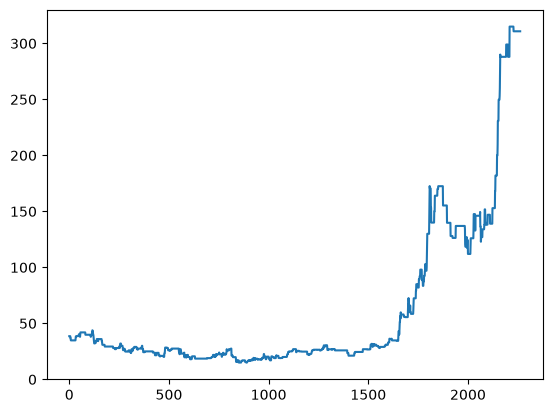

In [2]:
import matplotlib.pyplot as plt

plt.plot(jberger['close_price'])
plt.show()

In [3]:
jberger_end_month_df = (
    jberger
    .sort_values("date")
    .groupby(jberger["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

jberger_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45357,JBERGER,2017-01-31,34.83,34.83,20841,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47178,JBERGER,2017-02-28,38.66,38.66,285000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49294,JBERGER,2017-03-31,41.95,41.95,19693,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51122,JBERGER,2017-04-28,39.86,39.86,57695,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53044,JBERGER,2017-05-31,39.86,39.86,500,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35317,JBERGER,2026-03-31,288.00,288.00,280756,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281143,JBERGER,2026-04-30,315.00,315.00,994759,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284209,JBERGER,2026-05-29,315.00,315.00,73630,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294137,JBERGER,2026-06-30,310.80,310.80,4678,2026-06-30T15:10:03.08168+00:00,6,2,2026


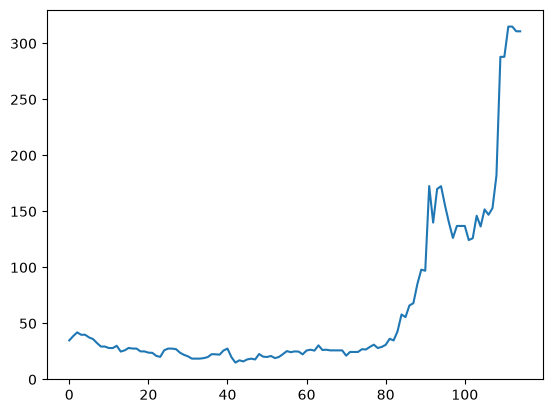

In [4]:
plt.plot(jberger_end_month_df['close_price'])
plt.show()

In [5]:
jberger_end_month_df['returns']=jberger_end_month_df['close_price'].pct_change()*100
jberger_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45357,JBERGER,2017-01-31,34.83,34.83,20841,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47178,JBERGER,2017-02-28,38.66,38.66,285000,2026-04-08T02:44:45.006295+00:00,2,1,2017,10.996268
2,49294,JBERGER,2017-03-31,41.95,41.95,19693,2026-04-08T02:45:42.281198+00:00,3,1,2017,8.510088
3,51122,JBERGER,2017-04-28,39.86,39.86,57695,2026-04-08T02:51:55.619599+00:00,4,2,2017,-4.982122
4,53044,JBERGER,2017-05-31,39.86,39.86,500,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35317,JBERGER,2026-03-31,288.00,288.00,280756,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281143,JBERGER,2026-04-30,315.00,315.00,994759,2026-04-30T15:00:02.170664+00:00,4,2,2026,9.375000
112,284209,JBERGER,2026-05-29,315.00,315.00,73630,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294137,JBERGER,2026-06-30,310.80,310.80,4678,2026-06-30T15:10:03.08168+00:00,6,2,2026,-1.333333


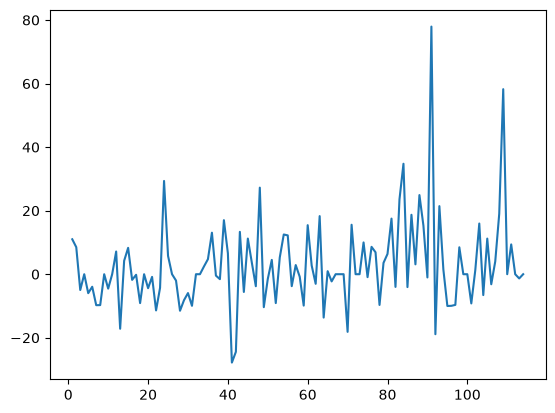

In [6]:
plt.plot(jberger_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(jberger_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-11.112624360582169), np.float64(3.628129399270228e-20), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(820.7871813434509))
stationary


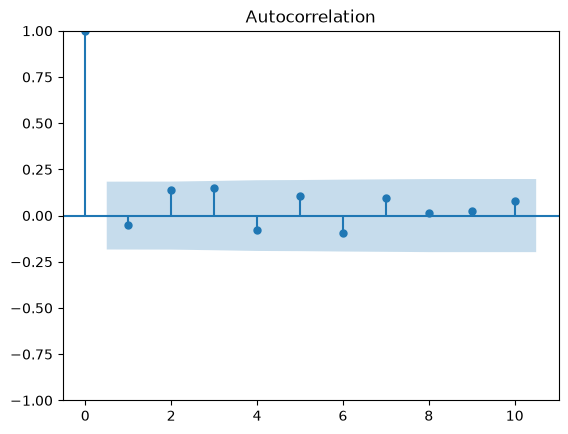

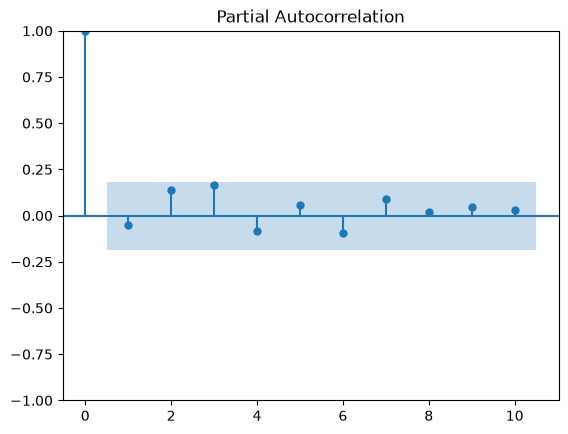

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(jberger_end_month_df['returns'].dropna(), lags=10)
plot_pacf(jberger_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=jberger_end_month_df['close_price'][:-10]
test=jberger_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -11.454788125006843]
[0, 0, 0, 0, 0, 1, -5.722076529798912]
[0, 0, 0, 0, 0, 2, -4.33071869575707]
[0, 0, 0, 0, 1, 0, -2.4787880046729054]
[0, 0, 0, 0, 1, 1, -2.1911787605448194]
[0, 0, 0, 0, 1, 2, -2.228149460783734]
[0, 0, 0, 0, 2, 0, -1.9639297792858494]
[0, 0, 0, 0, 2, 1, -1.4658896914845867]
[0, 0, 0, 0, 2, 2, -1.1537718054935668]
[0, 0, 0, 1, 0, 0, -3.015785233920762]
[0, 0, 0, 1, 0, 1, -2.771203180033115]
[0, 0, 0, 1, 0, 2, -3.0041402069896304]
[0, 0, 0, 1, 1, 0, -2.039544867012854]
[0, 0, 0, 1, 1, 1, -2.3538228040654077]
[0, 0, 0, 1, 1, 2, -2.2473400775026446]
[0, 0, 0, 1, 2, 0, -1.1961131254949202]
[0, 0, 0, 1, 2, 1, -1.2869205728225412]
[0, 0, 0, 1, 2, 2, -1.2175877565530748]
[0, 0, 0, 2, 0, 0, -2.5751340948139436]
[0, 0, 0, 2, 0, 1, -2.9506514827147816]
[0, 0, 0, 2, 0, 2, -2.939930758034101]
[0, 0, 0, 2, 1, 0, -2.016351163395899]
[0, 0, 0, 2, 1, 1, -2.191869861238373]
[0, 0, 0, 2, 1, 2, -2.1351675800062684]
[0, 0, 0, 2, 2, 0, -1.3768509602304042]
[0, 0, 0, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
653,2,2,0,0,2,0,-36.462970
410,1,2,0,0,2,0,-32.724076
707,2,2,2,0,2,0,-32.055883
680,2,2,1,0,2,0,-31.762517
464,1,2,2,0,2,0,-31.475964
...,...,...,...,...,...,...,...
178,0,2,0,1,2,1,0.220605
170,0,2,0,0,2,2,0.231978
169,0,2,0,0,2,1,0.372228
165,0,2,0,0,1,0,0.658839


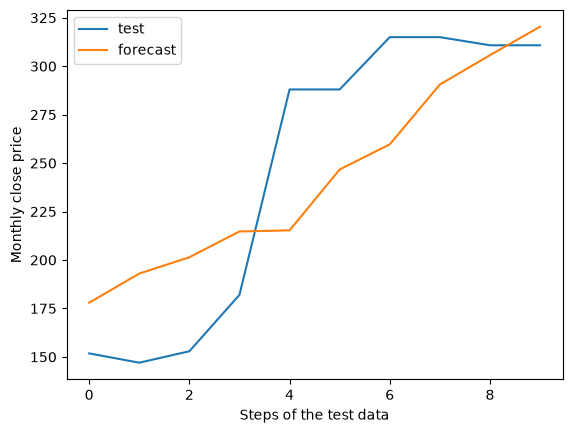

r2_score:  0.6786494868412012
rmse:  41.22498632667918
description:  count    115.000000
mean      62.442522
std       72.931071
min       15.000000
25%       23.775000
50%       27.500000
75%       61.975000
max      315.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=jberger_end_month_df['close_price'][:-10]
y_test=jberger_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(2,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', jberger_end_month_df.close_price.describe())

We will work with these.